# Multi-Head Self-Attention

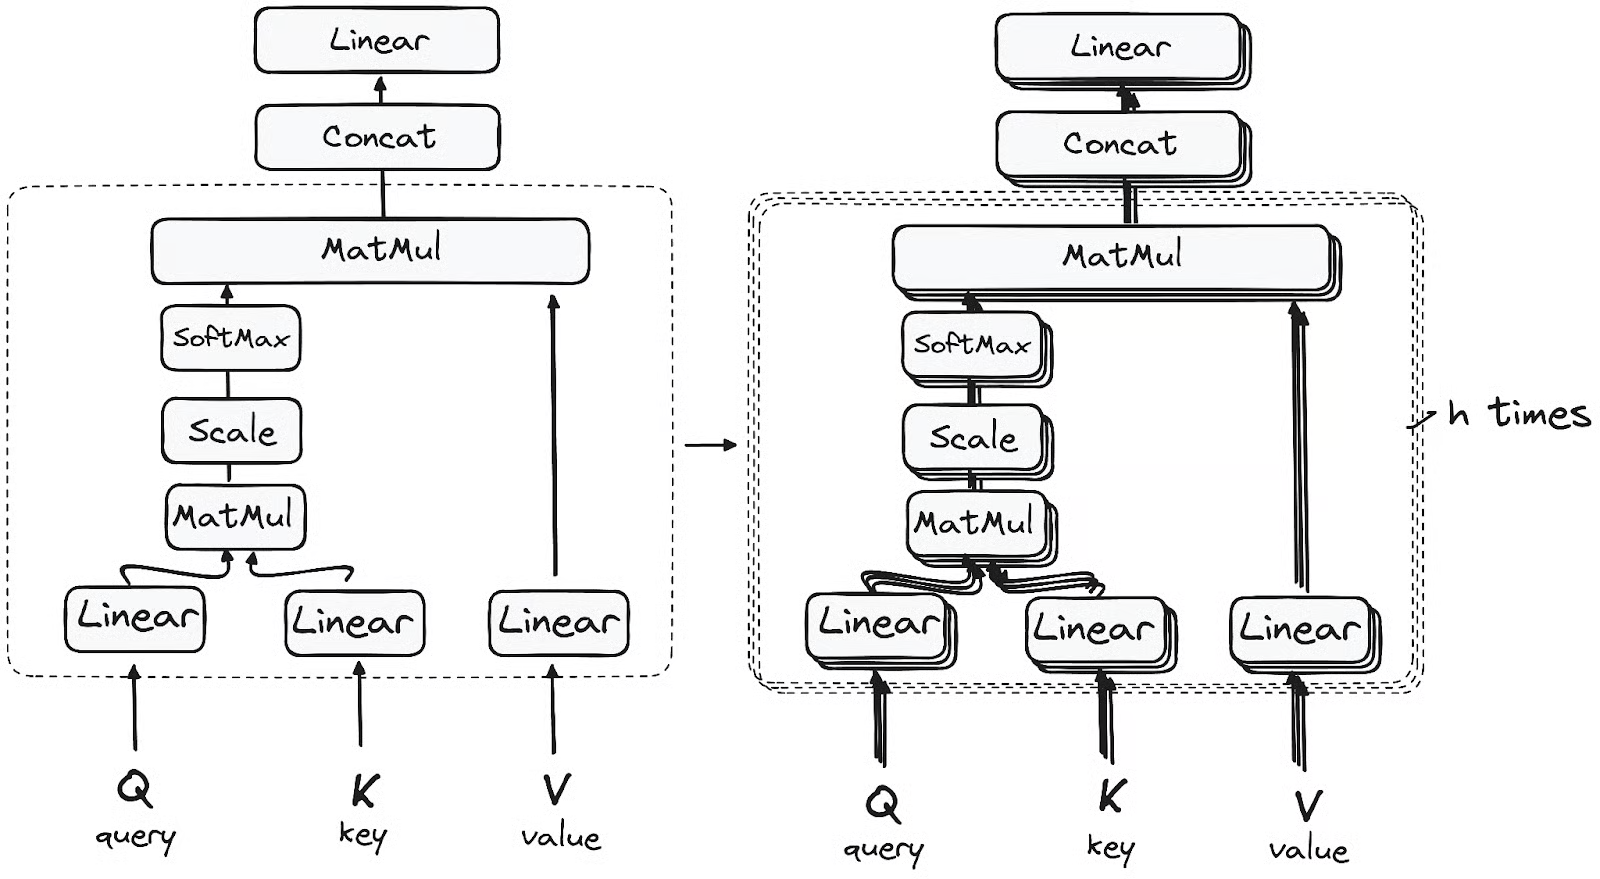

In [138]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Calculating Attention Scores

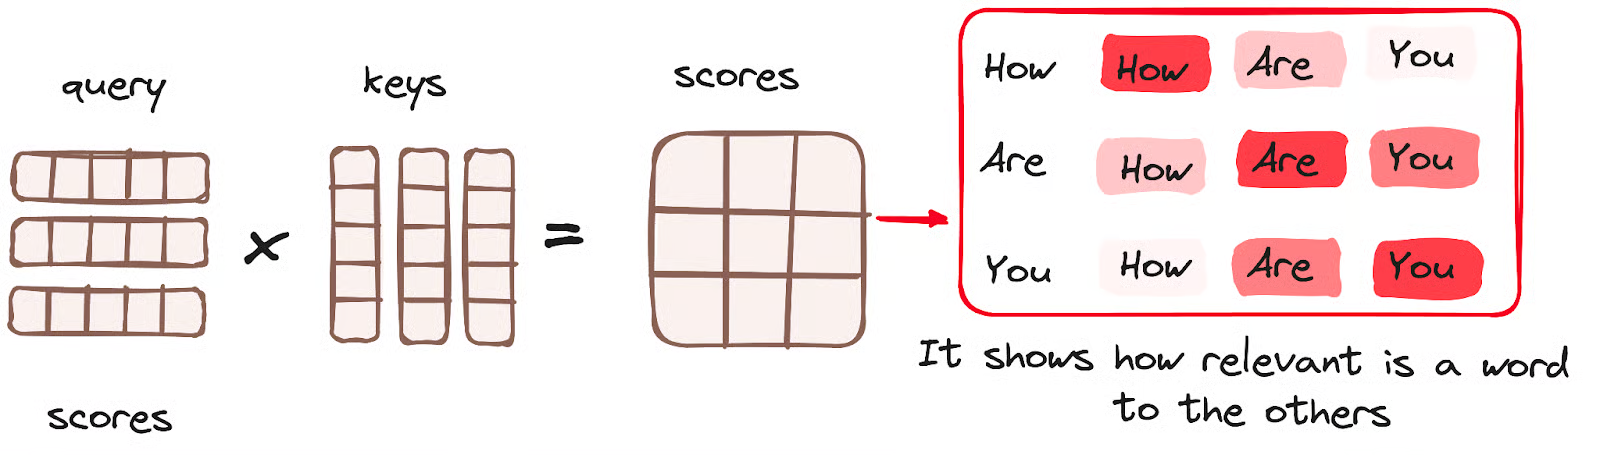

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [139]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # journey
   [0.55, 0.87, 0.66], # before
   [0.12, 0.48, 0.29], # destination  
   [0.57, 0.85, 0.64], # life
   [0.22, 0.58, 0.33], # before     
   [0.77, 0.25, 0.10]] # death
)

In [140]:
class DefaultSelfAttention(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.W_q = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.W_k = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.W_v = nn.Linear(embedding_dim, embedding_dim, bias=False)

    def forward(self, inputs):
        queries = self.W_q(inputs)
        keys = self.W_k(inputs)
        values = self.W_v(inputs)

        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / (queries.size(-1) ** 0.5)
        self.attention_weights = torch.softmax(attention_scores, dim=-1)
        return torch.matmul(self.attention_weights, values)

In [141]:
def plot_attention_heatmap(attention_weights, tokens, title="Attention Weights Heatmap"):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(attention_weights.detach().numpy(), cmap="Blues")

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticklabels(tokens)

    for i in range(len(tokens)):
        for j in range(len(tokens)):
            ax.text(j, i, f"{attention_weights[i, j]:.2f}", ha="center", va="center", fontsize=9)

    plt.colorbar(im, ax=ax, label="Attention Weight")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

Attention output shape: torch.Size([6, 3])


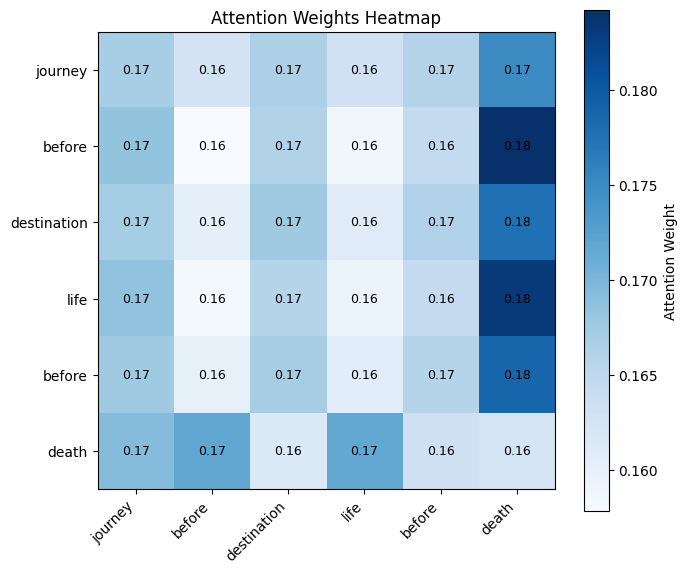

In [142]:
self_attention = DefaultSelfAttention(inputs.shape[1])
attention_output = self_attention(inputs)
print(f"Attention output shape: {attention_output.shape}")
tokens = ["journey", "before", "destination", "life", "before", "death"]
plot_attention_heatmap(self_attention.attention_weights, tokens)

## Masked Attention
We want the self-attention mechanism to consider only the tokens that appear prior to the current position when predicting the next token in a sequence, this is to avoid information leakage. Masked attention is used to achieve this. When working with sequence data like text, we can have input of varying length, in such cases we can use masking to handling inputs of different length

In [143]:
class MaskedSelfAttention(nn.Module):
    def __init__(self, context_length, bias=False):
        super().__init__()
        self.W_q = nn.Linear(context_length, context_length, bias=bias)
        self.W_k = nn.Linear(context_length, context_length, bias=bias)
        self.W_v = nn.Linear(context_length, context_length, bias=bias)
    
    def forward(self, inputs):
        queries = self.W_q(inputs)
        keys = self.W_k(inputs)
        values = self.W_v(inputs)

        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / (queries.size(-1) ** 0.5)
        mask = torch.triu(torch.ones(attention_scores.shape), diagonal=1)
        masked_attention_scores = attention_scores.masked_fill(mask.bool(), float("-inf"))
        self.attention_weights = torch.softmax(masked_attention_scores, dim=-1)
        return torch.matmul(self.attention_weights, values)

Attention output shape: torch.Size([6, 3])


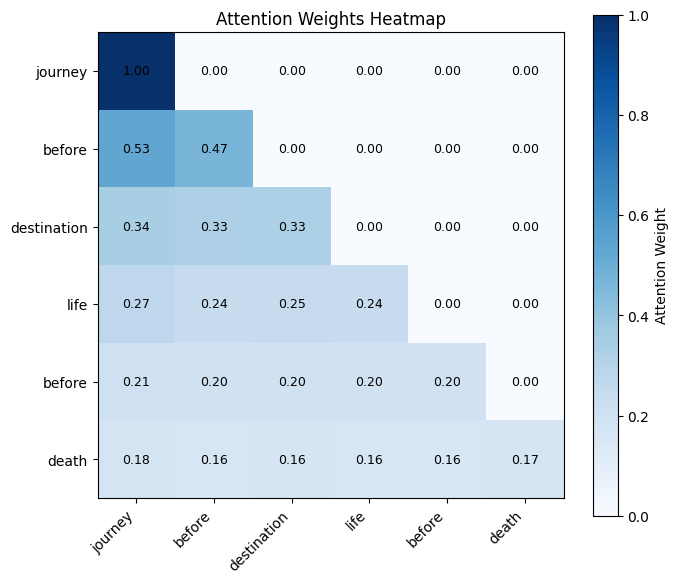

In [144]:
self_attention = MaskedSelfAttention(inputs.shape[1])
attention_output = self_attention(inputs)
print(f"Attention output shape: {attention_output.shape}")
tokens = ["journey", "before", "destination", "life", "before", "death"]
plot_attention_heatmap(self_attention.attention_weights, tokens)

## Dropout

In [145]:
class SelfAttention(nn.Module):
    def __init__(self, context_length, bias=False, dropout=0.1):
        super().__init__()
        self.W_q = nn.Linear(context_length, context_length, bias=bias)
        self.W_k = nn.Linear(context_length, context_length, bias=bias)
        self.W_v = nn.Linear(context_length, context_length, bias=bias)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, inputs):
        queries = self.W_q(inputs)
        keys = self.W_k(inputs)
        values = self.W_v(inputs)

        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / (queries.size(-1) ** 0.5)
        mask = torch.triu(torch.ones(attention_scores.shape), diagonal=1)
        masked_attention_scores = attention_scores.masked_fill(mask.bool(), float("-inf"))
        self.attention_weights = torch.softmax(masked_attention_scores, dim=-1)
        self.attention_weights = self.dropout(self.attention_weights)
        return torch.matmul(self.attention_weights, values)

Attention output shape: torch.Size([6, 3])


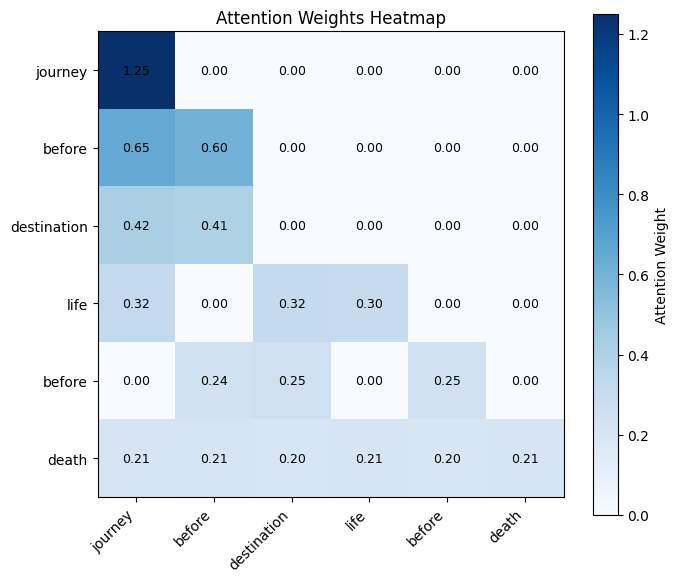

In [146]:
context_length = inputs.shape[1]
self_attention = SelfAttention(context_length, dropout=0.2)
attention_output = self_attention(inputs)
print(f"Attention output shape: {attention_output.shape}")
tokens = ["journey", "before", "destination", "life", "before", "death"]
plot_attention_heatmap(self_attention.attention_weights, tokens)

## Multi Head Self Attention

In [147]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, context_length, num_heads, bias=False, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttention(context_length, bias=bias, dropout=dropout) for _ in range(num_heads)
])
    
    def forward(self, inputs):
        head_outputs = [head(inputs) for head in self.heads]
        return torch.cat(head_outputs, dim=-1)


In [148]:
multi_head_attention = MultiHeadSelfAttention(context_length, num_heads=4, dropout=0.2)
attention_output = multi_head_attention(inputs)
print(f"Attention output shape: {attention_output.shape}")

Attention output shape: torch.Size([6, 12])
